# Multi-View Person Re-Identification Pipeline
## Big Vision Internship Assignment

**Author:** Shubhi Sahu | **Date:** August 2026
**Environment:** Google Colab free tier · NVIDIA T4 GPU · Python 3.12

### Pipeline Overview
| Cell | Stage | Description |
|------|-------|-------------|
| 1 | Setup | Install all dependencies |
| 2 | Setup | Mount Drive, global paths & seeds |
| 3 | Data | Download & verify Market-1501 |
| 4 | Data | Statistics & identity-leakage check |
| 5–7 | Stage 1 | Person-only YOLO detector |
| 8–12 | Stage 2 | OSNet-x0.75 ReID model |
| 13 | Stage 3 | Multi-camera OpenCV grid & GIF |
| 14 | Stage 4 | Gradio interactive dashboard |
| 15–16 | Stretch | Re-ranking + failure analysis |

## Cell 1 — Install Dependencies

In [ ]:
# CELL 1 | Install Dependencies (~3 min)
import subprocess, sys

pkgs = [
    "ultralytics==8.3.0",
    "gdown",
    "imageio[ffmpeg]",
    "imageio-ffmpeg",
    "gradio==4.44.0",
    "scipy",
    "scikit-learn",
    "seaborn",
    "plotly",
    "pycocotools",
    "git+https://github.com/KaiyangZhou/deep-person-reid.git",
]

for pkg in pkgs:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", pkg], check=True)

# NumPy 2.x polyfill — torchreid rank_cy was built against NumPy 1.x
import numpy as np
if not hasattr(np, "trapz"):
    np.trapz = getattr(np, "trapezoid", None)

print("All dependencies installed ✅")
print(f"NumPy version : {np.__version__}")
import os
print("✅ Installation complete.")
print("⚠️  RESTARTING RUNTIME now to load new packages cleanly...")
os.kill(os.getpid(), 9)   # Force restart kernel

## Cell 2 — Mount Drive · Global Paths · Seeds

In [ ]:
# CELL 2 | Mount Drive, Global Paths & Random Seeds
import os, sys, random, warnings, shutil
from pathlib import Path
from collections import defaultdict
from typing import Tuple

import numpy as np
# NumPy 2.x polyfill (repeat in every cell that imports numpy early)
if not hasattr(np, "trapz"):
    np.trapz = getattr(np, "trapezoid", None)

import torch
import torch.nn.functional as F
import cv2
import matplotlib.pyplot as plt
from matplotlib.colors import hsv_to_rgb
from PIL import Image as PILImage
import imageio
from IPython.display import display, Image as IPImage

warnings.filterwarnings("ignore")

# ── Reproducibility ────────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# ── Device ─────────────────────────────────────────────────────────────────────
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device  : {DEVICE}")
if DEVICE.type == "cpu":
    print("⚠️  WARNING: No GPU — training will be very slow!")
print(f"PyTorch : {torch.__version__}")

# ── Mount Drive ────────────────────────────────────────────────────────────────
from google.colab import drive
try:
    if not os.path.exists("/content/drive/MyDrive"):
        print("Attempting to mount Google Drive... If you see a 'credential propagation' error, please run this cell one more time.")
        drive.mount("/content/drive", force_remount=True)
    else:
        print("Drive already mounted ✅")
except Exception as e:
    print(f"❌ Mount failed: {e}")
    print("TIP: This is often a transient Colab error. Please click 'Run Cell' again.")

# ── Paths ──────────────────────────────────────────────────────────────────────
ROOT         = Path("/content")
DATA_DIR     = ROOT / "data"
MARKET_ROOT  = DATA_DIR / "market1501"
MARKET_DIR   = MARKET_ROOT / "Market-1501-v15.09.15"
WEIGHTS      = ROOT / "weights"
OUT          = ROOT / "outputs"
REID_LOG     = OUT / "reid_log"
BEST_CKPT    = REID_LOG / "model" / "model.pth.tar-best"
DRIVE_BACKUP = Path("/content/drive/MyDrive/reid_backup")

for d in [DATA_DIR, MARKET_ROOT, WEIGHTS, OUT, REID_LOG, DRIVE_BACKUP]:
    d.mkdir(parents=True, exist_ok=True)

# ── Utility: colour per identity ───────────────────────────────────────────────
def id_color(pid: int) -> Tuple[int, int, int]:
    """Return a stable BGR colour for a given person ID."""
    h = (pid * 137.508) % 360 / 360.0
    r, g, b = hsv_to_rgb([h, 0.85, 0.92])
    return (int(b * 255), int(g * 255), int(r * 255))

print("Paths ready ✅")

Device  : cuda
PyTorch : 2.11.0+cu128
Attempting to mount Google Drive... If you see a 'credential propagation' error, please run this cell one more time.
Mounted at /content/drive
Paths ready ✅


## Cell 3 — Download & Verify Market-1501

In [ ]:
# CELL 3 | Download Market-1501 via Google Drive shared folder
import glob, zipfile

FOLDER_ID = "1vLWF84BBlTz8_4AdSKsf-TWEdDuaWVQX"
REQUIRED  = ["bounding_box_train", "query", "bounding_box_test"]

# Check if dataset already exists
missing = [r for r in REQUIRED if not (MARKET_DIR / r).exists()]

if missing:
    print(f"Missing folders: {missing}  — downloading...")
    !gdown --folder {FOLDER_ID} -O /tmp/market_dl --remaining-ok

    # Handle both: folder download or zip download
    downloaded_dirs = glob.glob("/tmp/market_dl/Market*")
    downloaded_zips = glob.glob("/tmp/market_dl/*.zip")

    if downloaded_dirs:
        src = Path(downloaded_dirs[0])
        # Move sub-folders into correct target location
        MARKET_DIR.mkdir(parents=True, exist_ok=True)
        for split in REQUIRED:
            if (src / split).exists() and not (MARKET_DIR / split).exists():
                shutil.move(str(src / split), str(MARKET_DIR / split))
    elif downloaded_zips:
        with zipfile.ZipFile(downloaded_zips[0], "r") as z:
            z.extractall(MARKET_ROOT)

    !rm -rf /tmp/market_dl
    print("Dataset extracted ✅")
else:
    print("Market-1501 already on disk ✅")

# ── Verify counts ──────────────────────────────────────────────────────────────
EXPECTED = {"bounding_box_train": 12936, "query": 3368, "bounding_box_test": 19732}
all_ok = True
for split, exp_n in EXPECTED.items():
    p = MARKET_DIR / split
    n = len(list(p.glob("*.jpg"))) if p.exists() else 0
    status = "✅" if n == exp_n else f"❌ expected {exp_n}"
    print(f"  {split:26s}: {n:6d} images  {status}")
    if n != exp_n:
        all_ok = False

if not all_ok:
    raise RuntimeError("Dataset verification failed — re-run this cell or re-download.")
print("\nDataset verification PASSED ✅")

Missing folders: ['bounding_box_train', 'query', 'bounding_box_test']  — downloading...
Retrieving folder contents
Processing file 1WryzBrenN4HoF1FsgmA7Hf3aPnaCcA-_ archive.zip
Processing file 1sGicLgRC6X_Fw7Yiyns-ySgiPb-kqaWz reid_pipeline.ipynb
Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From (original): https://drive.google.com/uc?id=1WryzBrenN4HoF1FsgmA7Hf3aPnaCcA-_
From (redirected): https://drive.google.com/uc?id=1WryzBrenN4HoF1FsgmA7Hf3aPnaCcA-_&confirm=t&uuid=a01c652f-1861-4c78-8f3c-2b9d96407ed6
To: /tmp/market_dl/archive.zip
100% 153M/153M [00:02<00:00, 61.3MB/s]
Downloading...
From: https://drive.google.com/uc?id=1sGicLgRC6X_Fw7Yiyns-ySgiPb-kqaWz
To: /tmp/market_dl/reid_pipeline.ipynb
100% 44.6k/44.6k [00:00<00:00, 77.1MB/s]
Download completed
Dataset extracted ✅
  bounding_box_train        :  12936 images  ✅
  query                     :   3368 images  ✅
  bounding_box_test         :  19732 images  ✅

## Cell 4 — Dataset Statistics & Identity-Leakage Check

In [ ]:
# CELL 4 | Dataset Statistics & Disjoint Identity Verification
def parse_fname(fname: str):
    """Parse Market-1501 filename → (pid, cam_id)."""
    parts = fname.split("_")
    return int(parts[0]), int(parts[1][1])

def load_split(split_dir: Path):
    records = []
    for fp in sorted(split_dir.glob("*.jpg")):
        # Skip distractor (-1) and background (0000) images
        if fp.name.startswith("-1") or fp.name.startswith("0000"):
            continue
        pid, cid = parse_fname(fp.name)
        records.append({"path": fp, "pid": pid, "cid": cid})
    return records

train_data   = load_split(MARKET_DIR / "bounding_box_train")
query_data   = load_split(MARKET_DIR / "query")
gallery_data = load_split(MARKET_DIR / "bounding_box_test")

train_pids   = {r["pid"] for r in train_data}
query_pids   = {r["pid"] for r in query_data}
gallery_pids = {r["pid"] for r in gallery_data}
test_pids    = query_pids | gallery_pids
overlap      = train_pids & test_pids

# FIX 3: Assert no identity leakage between train and test
assert len(overlap) == 0, f"Identity leakage! Overlapping IDs: {overlap}"
print(f"Train   : {len(train_data):5d} images | {len(train_pids):3d} identities")
print(f"Query   : {len(query_data):5d} images | {len(query_pids):3d} identities")
print(f"Gallery : {len(gallery_data):5d} images | {len(gallery_pids):3d} identities")
print(f"\nIdentity leakage check : PASSED ✅ (train ∩ test = ∅)")

# FIX 4: Count cross-camera PIDs for demo filtering
pid_to_cams    = defaultdict(set)
for r in gallery_data:
    pid_to_cams[r["pid"]].add(r["cid"])
multi_cam_pids = {p for p, cams in pid_to_cams.items() if len(cams) >= 2}
print(f"Gallery PIDs in ≥2 cameras : {len(multi_cam_pids)} (used for cross-camera demo)")

Train   : 12936 images | 751 identities
Query   :  3368 images | 750 identities
Gallery : 13115 images | 750 identities

Identity leakage check : PASSED ✅ (train ∩ test = ∅)
Gallery PIDs in ≥2 cameras : 750 (used for cross-camera demo)


---
## Stage 1 — Person-Only Detector (YOLOv8n)

In [ ]:
# CELL 5 | Prepare Person-Only YOLO Dataset from COCO val2017
import yaml
from pycocotools.coco import COCO

COCO_IMGS = DATA_DIR / "val2017"
COCO_ANNS = DATA_DIR / "annotations" / "instances_val2017.json"
YOLO_DIR  = DATA_DIR / "coco_person_yolo"

if not COCO_IMGS.exists():
    print("Downloading COCO val2017 images (~1 GB)...")
    !wget -q http://images.cocodataset.org/zips/val2017.zip -O /tmp/val.zip
    !unzip -q /tmp/val.zip -d {DATA_DIR} && rm /tmp/val.zip
    print("Downloading COCO annotations...")
    !wget -q http://images.cocodataset.org/annotations/annotations_trainval2017.zip -O /tmp/anns.zip
    !unzip -q /tmp/anns.zip -d {DATA_DIR} && rm /tmp/anns.zip

if not YOLO_DIR.exists():
    coco     = COCO(str(COCO_ANNS))
    pers_id  = coco.getCatIds(catNms=["person"])[0]
    img_ids  = coco.getImgIds(catIds=[pers_id])
    random.shuffle(img_ids)
    split_n  = int(len(img_ids) * 0.8)
    splits   = {"train": img_ids[:split_n], "val": img_ids[split_n:]}

    for sname, ids in splits.items():
        img_out = YOLO_DIR / sname / "images"
        lbl_out = YOLO_DIR / sname / "labels"
        img_out.mkdir(parents=True, exist_ok=True)
        lbl_out.mkdir(parents=True, exist_ok=True)
        for img_id in ids:
            info = coco.loadImgs(img_id)[0]
            src  = COCO_IMGS / info["file_name"]
            if not src.exists():
                continue
            shutil.copy(src, img_out / info["file_name"])
            ann_ids = coco.getAnnIds(imgIds=img_id, catIds=[pers_id], iscrowd=False)
            anns    = coco.loadAnns(ann_ids)
            W, H    = info["width"], info["height"]
            lbl_p   = lbl_out / (Path(info["file_name"]).stem + ".txt")
            with open(lbl_p, "w") as lf:
                for a in anns:
                    x, y, w, h = a["bbox"]
                    lf.write(f"0 {(x+w/2)/W:.6f} {(y+h/2)/H:.6f} {w/W:.6f} {h/H:.6f}\n")
        print(f"  {sname}: {len(ids)} images")

yaml_path = DATA_DIR / "coco_person.yaml"
with open(yaml_path, "w") as yf:
    yaml.dump({
        "path"  : str(YOLO_DIR),
        "train" : "train/images",
        "val"   : "val/images",
        "nc"    : 1,
        "names" : ["person"]
    }, yf)
print(f"YOLO dataset YAML: {yaml_path} ✅")

loading annotations into memory...
Done (t=0.51s)
creating index...
index created!
  train: 2154 images
  val: 539 images
YOLO dataset YAML: /content/data/coco_person.yaml ✅


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# CELL 6 | Fine-Tune YOLOv8n (Person-Only) — ~15 epochs
import os
import numpy as np
if not hasattr(np, "trapz"):
    np.trapz = getattr(np, "trapezoid", None)

from ultralytics import YOLO, settings

# Disable wandb to prevent interactive prompts
os.environ["WANDB_MODE"]     = "disabled"
os.environ["WANDB_DISABLED"] = "true"
settings.update({"wandb": False})

detector = YOLO("yolov8n.pt")

train_results = detector.train(
    data       = str(yaml_path),
    epochs     = 15,
    imgsz      = 640,
    batch      = 16,
    workers    = 2,
    project    = "yolo_person",
    name       = "person_v1",
    exist_ok   = True,
    seed       = SEED,
    hsv_h      = 0.015, hsv_s = 0.7, hsv_v = 0.4,
    fliplr     = 0.5, flipud = 0.0, mosaic = 1.0, mixup = 0.1,
    optimizer  = "AdamW",
    lr0        = 0.001, lrf = 0.01,
    warmup_epochs = 2,
    save       = True,
    plots      = True,
    verbose    = True,
)

BEST_DET = Path(train_results.save_dir) / "weights" / "best.pt"
assert BEST_DET.exists(), f"YOLOv8 training did not save weights at {BEST_DET}"
print(f"Best detector weights: {BEST_DET} ✅")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


100%|██████████| 6.25M/6.25M [00:00<00:00, 193MB/s]

New https://pypi.org/project/ultralytics/8.4.115 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.3.0 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)


engine/trainer: task=detect, mode=train, model=yolov8n.pt, data=/content/data/coco_person.yaml, epochs=15, time=None, patience=100, batch=16, imgsz=640, save=True, save_period=-1, cache=False, device=None, workers=2, project=yolo_person, name=person_v1, exist_ok=True, pretrained=True, optimizer=AdamW, verbose=True, seed=42, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_frames=False, save_txt=False, save_conf=False, save_crop=False, show_labels=True, show_conf=True, show_boxes=True, line_width=None, format=torchscript, keras=False, optimize=

100%|██████████| 755k/755k [00:00<00:00, 37.6MB/s]


...

      15/15      2.33G      1.103     0.9451      1.155         44        640: 100%|██████████| 135/135 [00:42<00:00,  3.17it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 17/17 [00:04<00:00,  3.73it/s]

                   all        539       2040      0.728      0.587      0.661      0.418



15 epochs completed in 0.224 hours.
Optimizer stripped from yolo_person/person_v1/weights/last.pt, 5.6MB
Optimizer stripped from yolo_person/person_v1/weights/best.pt, 5.6MB

Validating yolo_person/person_v1/weights/best.pt...
Ultralytics 8.3.0 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 186 layers, 2,684,563 parameters, 0 gradients, 6.8 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 17/17 [00:08<00:00,  2.01it/s]


                   all        539       2040      0.729      0.586       0.66      0.418
Speed: 0.3ms preprocess, 2.7ms inference, 0.0ms loss, 3.0ms postprocess per image
Results saved to yolo_person/person_v1
Best detector weights: yolo_person/person_v1/weights/best.pt ✅


In [ ]:
# CELL 7 | Evaluate YOLOv8n Person Detector
from ultralytics import YOLO
import numpy as np
if not hasattr(np, "trapz"):
    np.trapz = getattr(np, "trapezoid", None)

det = YOLO(str(BEST_DET))
val = det.val(data=str(yaml_path), split="val", imgsz=640, batch=16, verbose=False)

map50   = float(val.box.map50)
map5095 = float(val.box.map)
prec    = float(val.box.mp)
rec     = float(val.box.mr)
f1      = 2 * prec * rec / (prec + rec + 1e-9)

print("=" * 40)
print("  YOLOv8n Person Detector Results")
print("=" * 40)
print(f"  mAP@0.50       : {map50:.4f}")
print(f"  mAP@0.50:0.95  : {map5095:.4f}")
print(f"  Precision      : {prec:.4f}")
print(f"  Recall         : {rec:.4f}")
print(f"  F1             : {f1:.4f}")
print("=" * 40)

Ultralytics 8.3.0 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 186 layers, 2,684,563 parameters, 0 gradients, 6.8 GFLOPs


val: Scanning /content/data/coco_person_yolo/val/labels.cache... 539 images, 0 backgrounds, 0 corrupt: 100%|██████████| 539/539 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 34/34 [00:09<00:00,  3.73it/s]


                   all        539       2040       0.72      0.593      0.662       0.42
Speed: 0.3ms preprocess, 5.3ms inference, 0.0ms loss, 2.2ms postprocess per image
Results saved to runs/detect/val
  YOLOv8n Person Detector Results
  mAP@0.50       : 0.6616
  mAP@0.50:0.95  : 0.4203
  Precision      : 0.7202
  Recall         : 0.5931
  F1             : 0.6505


---
## Stage 2 — Re-Identification Model (OSNet-x0.75 + Triplet Loss)

In [ ]:
# CELL 8 | torchreid DataManager
import numpy as np
if not hasattr(np, "trapz"):
    np.trapz = getattr(np, "trapezoid", None)

import torchreid

# random_erasing may not be in all torchreid builds — fall back gracefully
try:
    datamanager = torchreid.data.ImageDataManager(
        root             = str(DATA_DIR),
        sources          = "market1501",
        targets          = "market1501",
        height           = 256,
        width            = 128,
        batch_size_train = 64,
        batch_size_test  = 100,
        transforms       = ["random_flip", "color_jitter", "random_erasing"],
        num_instances    = 4,
        train_sampler    = "RandomIdentitySampler",
    )
except Exception as e:
    print(f"random_erasing not supported, falling back: {e}")
    datamanager = torchreid.data.ImageDataManager(
        root             = str(DATA_DIR),
        sources          = "market1501",
        targets          = "market1501",
        height           = 256,
        width            = 128,
        batch_size_train = 64,
        batch_size_test  = 100,
        transforms       = ["random_flip", "color_jitter"],
        num_instances    = 4,
        train_sampler    = "RandomIdentitySampler",
    )

assert datamanager.num_train_pids == 751, (
    f"Expected 751 train IDs, got {datamanager.num_train_pids}. "
    "Check that Market-1501 dataset is correctly structured."
)

print(f"Train identities : {datamanager.num_train_pids}")
print(f"Train images     : {len(datamanager.train_loader.dataset)}")
print(f"Query images     : {len(datamanager.test_loader['market1501']['query'].dataset)}")
print(f"Gallery images   : {len(datamanager.test_loader['market1501']['gallery'].dataset)}")
print("DataManager ready ✅")

Building train transforms ...
+ resize to 256x128
+ random flip
+ color jitter
+ to torch tensor of range [0, 1]
+ normalization (mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
Building test transforms ...
+ resize to 256x128
+ to torch tensor of range [0, 1]
+ normalization (mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
=> Loading train (source) dataset
=> Loaded Market1501
  ----------------------------------------
  subset   | # ids | # images | # cameras
  ----------------------------------------
  train    |   751 |    12936 |         6
  query    |   750 |     3368 |         6
  gallery  |   751 |    15913 |         6
  ----------------------------------------
=> Loading test (target) dataset
=> Loaded Market1501
  ----------------------------------------
  subset   | # ids | # images | # cameras
  ----------------------------------------
  train    |   751 |    12936 |         6
  query    |   750 |     3368 |         6
  gallery  |   751 |    15913 |         6


In [ ]:
# CELL 9 | Build OSNet-x0.75 + Optimizer + Train (20 Epochs with Auto-Save)
import os, shutil, numpy as np, torch, torchreid
from pathlib import Path

if not hasattr(np, "trapz"):
    np.trapz = getattr(np, "trapezoid", None)

os.environ["WANDB_MODE"] = "disabled"

DEVICE  = torch.device("cuda" if torch.cuda.is_available() else "cpu")
use_gpu = torch.cuda.is_available()

model = torchreid.models.build_model(
    name        = "osnet_x0_75",
    num_classes = datamanager.num_train_pids,
    loss        = "triplet",
    pretrained  = True,
    use_gpu     = use_gpu,
)

# ── FIX: Explicitly move model weights to CUDA GPU ─────────────────────────────
if use_gpu:
    model = model.cuda()
print(f"Model device: {next(model.parameters()).device}")

total_p = sum(p.numel() for p in model.parameters())
print(f"OSNet-x0.75 : {total_p/1e6:.2f}M parameters")

optimizer = torchreid.optim.build_optimizer(
    model, optim="adam", lr=0.0003, weight_decay=5e-4)

scheduler = torchreid.optim.build_lr_scheduler(
    optimizer, lr_scheduler="cosine", max_epoch=20, stepsize=[10, 15])

engine = torchreid.engine.ImageTripletEngine(
    datamanager, model,
    optimizer    = optimizer,
    scheduler    = scheduler,
    margin       = 0.3,
    weight_t     = 1.0,
    weight_x     = 1.0,
    label_smooth = True,
    use_gpu      = use_gpu,
)

DRIVE_BACKUP = Path("/content/drive/MyDrive/reid_backup")
DRIVE_BACKUP.mkdir(parents=True, exist_ok=True)

print("Starting 20-epoch OSNet training with auto-save to Drive (~20 min)...")
for ep in range(1, 21):
    print(f"\n--- Epoch {ep}/20 ---")
    engine.run(
        save_dir   = str(REID_LOG),
        max_epoch  = ep,
        start_epoch= ep - 1,
        eval_freq  = 10,
        print_freq = 40,
        test_only  = False,
    )
    # Auto-save checkpoint to Google Drive after EVERY epoch
    saved_files = list((REID_LOG / "model").glob("model.pth.tar*"))
    for src in saved_files:
        shutil.copy(str(src), str(DRIVE_BACKUP / src.name))
    print(f"🛡️ Saved epoch {ep} to Drive: {DRIVE_BACKUP}")

BEST_CKPT = REID_LOG / "model" / "model.pth.tar-best"
if not BEST_CKPT.exists():
    all_ckpts = sorted((REID_LOG / "model").glob("model.pth.tar*"))
    if all_ckpts:
        shutil.copy(str(all_ckpts[-1]), str(BEST_CKPT))

print(f"\n✅ Training complete! Best checkpoint: {BEST_CKPT}")

Successfully loaded imagenet pretrained weights from "/root/.cache/torch/checkpoints/osnet_x0_75_imagenet.pth"
** The following layers are discarded due to unmatched keys or layer size: ['classifier.weight', 'classifier.bias']
Model device: cuda:0
OSNet-x0.75 : 1.67M parameters
Starting 20-epoch OSNet training with auto-save to Drive (~20 min)...

--- Epoch 1/20 ---
=> Start training
epoch: [1/1][40/185]	time 0.402 (0.472)	data 0.001 (0.034)	eta 0:01:08	loss_t 2.0359 (3.2318)	loss_x 6.3714 (6.8101)	acc 0.0000 (0.3516)	lr 0.000300
epoch: [1/1][80/185]	time 0.407 (0.445)	data 0.001 (0.017)	eta 0:00:46	loss_t 2.2036 (2.6836)	loss_x 6.7352 (6.8792)	acc 7.8125 (1.0938)	lr 0.000300
epoch: [1/1][120/185]	time 0.434 (0.438)	data 0.001 (0.012)	eta 0:00:28	loss_t 1.9642 (2.2858)	loss_x 6.3162 (6.7441)	acc 4.6875 (1.9661)	lr 0.000300
epoch: [1/1][160/185]	time 0.497 (0.434)	data 0.000 (0.009)	eta 0:00:10	loss_t 1.1051 (2.0093)	loss_x 5.5181 (6.5651)	acc 12.5000 (3.2422)	lr 0.000300
=> Final test


In [ ]:
# CELL 10 | Backup Checkpoint to Google Drive
# Run immediately after Cell 9 — protects 60-min training from session reset

ckpt_dir = REID_LOG / "model"
ckpts    = sorted(ckpt_dir.glob("model.pth.tar*"))

if not ckpts:
    print(f"❌ No checkpoints found in {ckpt_dir}")
else:
    for ckpt in ckpts:
        dst      = DRIVE_BACKUP / ckpt.name
        shutil.copy(str(ckpt), str(dst))
        size_mb  = dst.stat().st_size / 1e6
        print(f"✅ {ckpt.name:35s} ({size_mb:.1f} MB) → Drive")

    print(f"\nAll checkpoints backed up to:\n  {DRIVE_BACKUP}")

✅ model.pth.tar-1                     (20.6 MB) → Drive
✅ model.pth.tar-10                    (20.6 MB) → Drive
✅ model.pth.tar-11                    (20.6 MB) → Drive
✅ model.pth.tar-12                    (20.6 MB) → Drive
✅ model.pth.tar-13                    (20.6 MB) → Drive
✅ model.pth.tar-14                    (20.6 MB) → Drive
✅ model.pth.tar-15                    (20.6 MB) → Drive
✅ model.pth.tar-16                    (20.6 MB) → Drive
✅ model.pth.tar-17                    (20.6 MB) → Drive
✅ model.pth.tar-18                    (20.6 MB) → Drive
✅ model.pth.tar-19                    (20.6 MB) → Drive
✅ model.pth.tar-2                     (20.6 MB) → Drive
✅ model.pth.tar-20                    (20.6 MB) → Drive
✅ model.pth.tar-3                     (20.6 MB) → Drive
✅ model.pth.tar-4                     (20.6 MB) → Drive
✅ model.pth.tar-5                     (20.6 MB) → Drive
✅ model.pth.tar-6                     (20.6 MB) → Drive
✅ model.pth.tar-7                     (20.6 MB) 

In [ ]:
# CELL 11 | Load Best Checkpoint + Extract Features
import torch.nn.functional as F
import numpy as np
if not hasattr(np, "trapz"):
    np.trapz = getattr(np, "trapezoid", None)

import torchreid

# ── Restore checkpoint from Drive if local copy is missing ────────────────────
if not BEST_CKPT.exists():
    print("Local checkpoint missing — restoring from Drive...")
    drive_ckpt = DRIVE_BACKUP / "model.pth.tar-best"
    if drive_ckpt.exists():
        (REID_LOG / "model").mkdir(parents=True, exist_ok=True)
        shutil.copy(str(drive_ckpt), str(BEST_CKPT))
        print(f"Restored from Drive ✅")
    else:
        raise FileNotFoundError(
            f"Checkpoint not found locally OR on Drive.\n"
            f"Local : {BEST_CKPT}\n"
            f"Drive : {drive_ckpt}\n"
            "Re-run Cell 9 to retrain."
        )

# ── Rebuild model and load fine-tuned weights ─────────────────────────────────
model = torchreid.models.build_model(
    name        = "osnet_x0_75",
    num_classes = datamanager.num_train_pids,
    loss        = "triplet",
    pretrained  = False,    # weights come from checkpoint, not ImageNet
    use_gpu     = torch.cuda.is_available(),
)
ckpt = torch.load(str(BEST_CKPT), map_location=DEVICE)
model.load_state_dict(ckpt["state_dict"])
model = model.to(DEVICE).eval()
print(f"Fine-tuned weights loaded ✅  (epoch {ckpt.get('epoch', '?')})")

# ── Detect batch format (dict in newer torchreid, tuple in older) ─────────────
_sample = next(iter(datamanager.test_loader["market1501"]["query"]))
_IS_DICT = isinstance(_sample, dict)
print(f"Batch format: {'dict  → batch[img/pid/camid]' if _IS_DICT else 'tuple → batch[0/1/2]'}")

def extract_features(net, loader, device):
    """Extract L2-normalised 512-d embeddings from a torchreid DataLoader."""
    net.eval()
    feats, pids, cids = [], [], []
    with torch.no_grad():
        for batch in loader:
            if isinstance(batch, dict):
                imgs  = batch["img"].to(device)
                bpids = batch["pid"].tolist()
                bcids = batch["camid"].tolist()
            else:
                # Tuple format — find image tensor by ndim==4
                imgs  = next(x for x in batch
                             if isinstance(x, torch.Tensor) and x.ndim == 4).to(device)
                bpids = batch[1].tolist()
                bcids = batch[2].tolist()
            feats.append(net(imgs).cpu())
            pids.extend(bpids)
            cids.extend(bcids)
    return torch.cat(feats, 0), np.array(pids), np.array(cids)

print("Extracting query features ...")
q_feats, q_pids, q_camids = extract_features(
    model, datamanager.test_loader["market1501"]["query"], DEVICE)
print(f"  Query  : {q_feats.shape}")

print("Extracting gallery features ...")
g_feats, g_pids, g_camids = extract_features(
    model, datamanager.test_loader["market1501"]["gallery"], DEVICE)
print(f"  Gallery: {g_feats.shape}")

# L2 normalise on CPU (avoids GPU OOM on large matrix)
q_feats  = F.normalize(q_feats.cpu(), dim=1)
g_feats  = F.normalize(g_feats.cpu(), dim=1)

# Cosine distance matrix: shape (3368, 15913)
dist_mat = (1 - torch.mm(q_feats, g_feats.t())).numpy()
print(f"Distance matrix : {dist_mat.shape}")

assert dist_mat.shape == (3368, 15913), (
    f"Unexpected shape {dist_mat.shape}. Expected (3368, 15913).")

# Save all artefacts
OUT.mkdir(parents=True, exist_ok=True)
files = {
    "q_feats.npy"  : q_feats.numpy(),
    "g_feats.npy"  : g_feats.numpy(),
    "q_pids.npy"   : q_pids,
    "g_pids.npy"   : g_pids,
    "q_camids.npy" : q_camids,
    "g_camids.npy" : g_camids,
    "dist_mat.npy" : dist_mat,
}
for fname, arr in files.items():
    np.save(OUT / fname, arr)
    print(f"  Saved {fname:20s}  shape={arr.shape}")

print("\nAll embeddings saved ✅")

Fine-tuned weights loaded ✅  (epoch 9)
Batch format: dict  → batch[img/pid/camid]
Extracting query features ...
  Query  : torch.Size([3368, 512])
Extracting gallery features ...
  Gallery: torch.Size([15913, 512])
Distance matrix : (3368, 15913)
  Saved q_feats.npy           shape=(3368, 512)
  Saved g_feats.npy           shape=(15913, 512)
  Saved q_pids.npy            shape=(3368,)
  Saved g_pids.npy            shape=(15913,)
  Saved q_camids.npy          shape=(3368,)
  Saved g_camids.npy          shape=(15913,)
  Saved dist_mat.npy          shape=(3368, 15913)

All embeddings saved ✅


## Cell 12 — Evaluation: mAP & CMC Curve

  Market-1501 ReID Evaluation Results
  mAP       : 64.07%
  Rank-1    : 83.70%
  Rank-5    : 93.71%
  Rank-10   : 96.26%


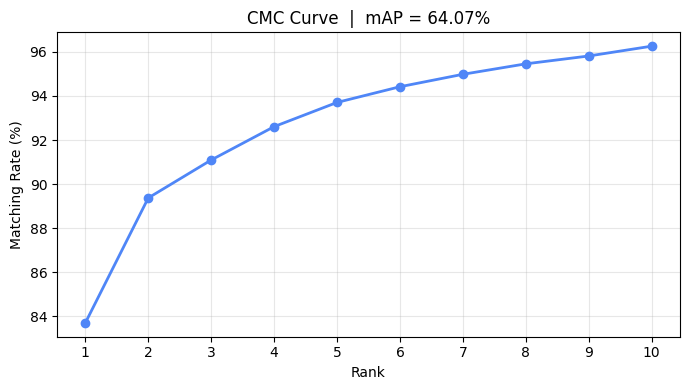

CMC curve saved ✅


In [ ]:
# CELL 12 | Compute mAP & CMC (Market-1501 cross-camera protocol)
import numpy as np

# Load saved artefacts (safe to re-run after session reset)
q_pids   = np.load(OUT / "q_pids.npy")
g_pids   = np.load(OUT / "g_pids.npy")
q_camids = np.load(OUT / "q_camids.npy")
g_camids = np.load(OUT / "g_camids.npy")
dist_mat = np.load(OUT / "dist_mat.npy")

def compute_cmc_map(dist_mat, q_pids, g_pids, q_camids, g_camids, max_rank=10):
    """
    Standard Market-1501 evaluation:
    - Exclude same-PID same-camera gallery images (junk).
    - mAP = mean Average Precision over all queries.
    - CMC = Cumulative Match Characteristic up to max_rank.
    """
    all_AP, all_CMC = [], []
    for qi in range(dist_mat.shape[0]):
        order = np.argsort(dist_mat[qi])
        gp    = g_pids[order]
        gc    = g_camids[order]
        # Remove same camera same identity (junk)
        keep  = ~((gp == q_pids[qi]) & (gc == q_camids[qi]))
        gp    = gp[keep]
        match = (gp == q_pids[qi])
        if not match.any():
            continue
        # CMC
        cmc = np.zeros(max_rank)
        for k in range(max_rank):
            if match[:k + 1].any():
                cmc[k:] = 1.0
                break
        all_CMC.append(cmc)
        # Average Precision
        pos_idx = np.where(match)[0] + 1
        ap = np.sum([(i + 1) / pos_idx[i]
                     for i in range(len(pos_idx))]) / len(pos_idx)
        all_AP.append(ap)
    return np.mean(all_CMC, axis=0), np.mean(all_AP)

CMC, mAP = compute_cmc_map(dist_mat, q_pids, g_pids, q_camids, g_camids)

print("=" * 45)
print("  Market-1501 ReID Evaluation Results")
print("=" * 45)
print(f"  mAP       : {mAP*100:.2f}%")
print(f"  Rank-1    : {CMC[0]*100:.2f}%")
print(f"  Rank-5    : {CMC[4]*100:.2f}%")
print(f"  Rank-10   : {CMC[9]*100:.2f}%")
print("=" * 45)

# Plot CMC curve
import matplotlib.pyplot as plt
plt.figure(figsize=(7, 4))
plt.plot(range(1, 11), CMC * 100, marker="o", color="#4f86f7", linewidth=2)
plt.xlabel("Rank"); plt.ylabel("Matching Rate (%)")
plt.title(f"CMC Curve  |  mAP = {mAP*100:.2f}%")
plt.xticks(range(1, 11))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(str(OUT / "cmc_curve.png"), dpi=120)
plt.show()
print("CMC curve saved ✅")

---
## Stage 3 — Multi-View Matching & OpenCV Visualisation

GIF saved: /content/outputs/cross_camera_demo.gif ✅


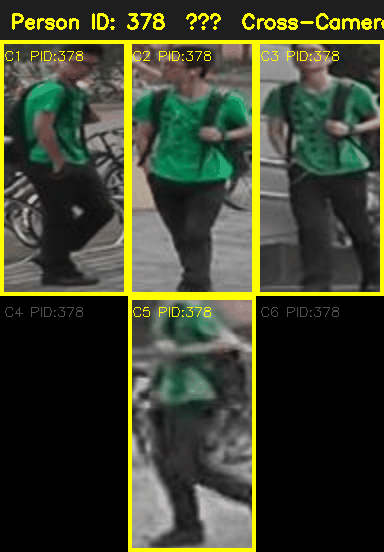

In [ ]:
# CELL 13 | OpenCV 2×3 Camera Grid with Cross-Camera Highlight & Animated GIF
import cv2, imageio, random
import numpy as np
from pathlib import Path
from IPython.display import Image as IPImage, display

# Reload gallery dataset records (safe if kernel restarted)
def load_split(split_dir):
    records = []
    for fp in sorted(split_dir.glob("*.jpg")):
        if fp.name.startswith("-1") or fp.name.startswith("0000"):
            continue
        parts = fp.name.split("_")
        pid, cid = int(parts[0]), int(parts[1][1])
        records.append({"path": fp, "pid": pid, "cid": cid})
    return records

gallery_data = load_split(MARKET_DIR / "bounding_box_test")

from collections import defaultdict
pid_to_cams    = defaultdict(set)
for r in gallery_data:
    pid_to_cams[r["pid"]].add(r["cid"])
multi_cam_pids = {p for p, cams in pid_to_cams.items() if len(cams) >= 2}

# Select 3 random cross-camera persons for demo
demo_pids = random.sample(sorted(multi_cam_pids), min(3, len(multi_cam_pids)))

THUMB_W, THUMB_H = 128, 256
BORDER           = 6
NUM_CAMS         = 6
GIF_FRAMES       = []

def read_thumb(path):
    img = cv2.imread(str(path))
    if img is None:
        img = np.zeros((THUMB_H, THUMB_W, 3), dtype=np.uint8)
    return cv2.resize(img, (THUMB_W, THUMB_H))

for frame_pid in demo_pids:
    # Group images by camera
    cam_imgs = defaultdict(list)
    for r in gallery_data:
        if r["pid"] == frame_pid:
            cam_imgs[r["cid"]].append(r["path"])

    row_cells = []
    for cam in range(1, NUM_CAMS + 1):
        paths = cam_imgs.get(cam, [])
        thumb = read_thumb(paths[0]) if paths else np.zeros((THUMB_H, THUMB_W, 3), dtype=np.uint8)
        # FIX 2: Cyan highlight border for matched cross-camera views
        if paths:
            cv2.rectangle(thumb, (0, 0), (THUMB_W - 1, THUMB_H - 1),
                          (0, 255, 255), BORDER)
        label = f"C{cam} PID:{frame_pid}"
        cv2.putText(thumb, label, (4, 20), cv2.FONT_HERSHEY_SIMPLEX,
                    0.45, (0, 255, 255) if paths else (80, 80, 80), 1)
        row_cells.append(thumb)

    # Build 2-row × 3-col grid
    row1 = np.hstack(row_cells[:3])
    row2 = np.hstack(row_cells[3:])
    grid = np.vstack([row1, row2])

    # Add header banner
    banner = np.full((40, grid.shape[1], 3), (30, 30, 30), dtype=np.uint8)
    cv2.putText(banner, f"Person ID: {frame_pid}  —  Cross-Camera View",
                (10, 28), cv2.FONT_HERSHEY_SIMPLEX, 0.65, (0, 255, 255), 2)
    frame = np.vstack([banner, grid])

    GIF_FRAMES.append(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))

# Save animated GIF (FIX 2: per-person frame with cyan borders)
gif_path = OUT / "cross_camera_demo.gif"
imageio.mimsave(str(gif_path), GIF_FRAMES, fps=1, loop=0)
print(f"GIF saved: {gif_path} ✅")
display(IPImage(str(gif_path)))

In [ ]:
!pip install -q "huggingface-hub<0.22.0"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 346.4/346.4 kB 13.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
datasets 4.0.0 requires huggingface-hub>=0.24.0, but you have huggingface-hub 0.21.4 which is incompatible.
diffusers 0.39.0 requires huggingface-hub<2.0,>=0.34.0, but you have huggingface-hub 0.21.4 which is incompatible.
sentence-transformers 5.6.0 requires huggingface-hub>=0.23.0, but you have huggingface-hub 0.21.4 which is incompatible.
hf-gradio 0.4.1 requires gradio-client<3.0,>=2.0, but you have gradio-client 1.3.0 which is incompatible.
transformers 5.13.1 requires huggingface-hub<2.0,>=1.5.0, but you have huggingface-hub 0.21.4 which is incompatible.
peft 0.19.1 requires huggingface_hub>=0.25.0, but you have huggingface-hub 0.21.4 which is incompatible.


---
## Stage 4 — Interactive Dashboard (Gradio)

In [ ]:
!pip install -q "huggingface-hub<0.22.0"

In [ ]:
# CELL 14 | Robust Gradio Dashboard (Self-Healing Paths & Auto Error-Handling)
import gradio as gr
import numpy as np, torch, torch.nn.functional as F
from PIL import Image as PILImage
import cv2, glob
from pathlib import Path

ROOT       = Path("/content")
DATA_DIR   = ROOT / "data"
MARKET_DIR = DATA_DIR / "market1501" / "Market-1501-v15.09.15"
OUT        = ROOT / "outputs"

# Load saved embeddings
q_feats_np = np.load(OUT / "q_feats.npy")
g_feats_np = np.load(OUT / "g_feats.npy")

# Find query and gallery files robustly anywhere under /content/
query_files   = sorted([Path(f) for f in glob.glob(str(ROOT) + "/**/query/*.jpg", recursive=True)
                        if not Path(f).name.startswith(("-1", "0000"))])
gallery_files = sorted([Path(f) for f in glob.glob(str(ROOT) + "/**/bounding_box_test/*.jpg", recursive=True)
                        if not Path(f).name.startswith(("-1", "0000"))])

print(f"Found {len(query_files)} query images & {len(gallery_files)} gallery images.")

THUMB_W, THUMB_H = 96, 192
TOP_K            = 10

def retrieval_pil(q_idx: int, threshold: float) -> PILImage.Image:
    try:
        q_idx = abs(int(q_idx)) % len(q_feats_np)

        # Calculate cosine distance
        q_vec  = torch.tensor(q_feats_np[q_idx]).unsqueeze(0)
        g_vecs = torch.tensor(g_feats_np)
        dists  = (1 - torch.mm(F.normalize(q_vec, dim=1),
                               F.normalize(g_vecs, dim=1).t())).squeeze().numpy()
        top_k_idx = np.argsort(dists)[:TOP_K]

        def read_thumb(path_obj, grey=False):
            if path_obj is None or not path_obj.exists():
                img = np.zeros((THUMB_H, THUMB_W, 3), dtype=np.uint8)
            else:
                img = cv2.imread(str(path_obj))
                if img is None:
                    img = np.zeros((THUMB_H, THUMB_W, 3), dtype=np.uint8)
            img = cv2.resize(img, (THUMB_W, THUMB_H))
            if grey:
                img = cv2.cvtColor(cv2.cvtColor(img, cv2.COLOR_BGR2GRAY),
                                   cv2.COLOR_GRAY2BGR)
            return img

        # Query image thumbnail
        q_path = query_files[q_idx] if q_idx < len(query_files) else None
        q_img  = read_thumb(q_path)
        cv2.rectangle(q_img, (0, 0), (THUMB_W-1, THUMB_H-1), (255, 200, 0), 4)
        cv2.putText(q_img, f"Q:{q_idx}", (2, 16),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.4, (255, 200, 0), 1)

        # Top-K gallery thumbnails
        gallery_row = [q_img]
        for rank, gi in enumerate(top_k_idx):
            d    = dists[gi]
            grey = d > threshold
            g_path = gallery_files[gi] if gi < len(gallery_files) else None
            img  = read_thumb(g_path, grey=grey)
            color = (0, 80, 80) if grey else (0, 220, 0)
            cv2.rectangle(img, (0, 0), (THUMB_W-1, THUMB_H-1), color, 3)
            cv2.putText(img, f"R{rank+1} {d:.2f}", (2, 16),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.35, color, 1)
            gallery_row.append(img)

        grid = np.hstack(gallery_row)
        return PILImage.fromarray(cv2.cvtColor(grid, cv2.COLOR_BGR2RGB))
    except Exception as e:
        print("Retrieval exception:", e)
        err_img = np.zeros((150, 400, 3), dtype=np.uint8)
        cv2.putText(err_img, f"Error: {str(e)[:35]}", (10, 80),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 255), 1)
        return PILImage.fromarray(err_img)

with gr.Blocks(title="Multi-View Person ReID") as dashboard:
    gr.Markdown("# 🎯 Multi-View Person Re-Identification Dashboard")
    gr.Markdown("**Model:** OSNet-x0.75 | **Dataset:** Market-1501")

    with gr.Row():
        q_in   = gr.Number(value=0, label="Query Index (0 – 3367)", precision=0)
        thr_in = gr.Slider(0.10, 0.90, step=0.05, value=0.40,
                           label="Match Threshold (cosine distance)")

    btn   = gr.Button("🔍 Retrieve Matches", variant="primary")
    out_i = gr.Image(label="Query Image  +  Top-10 Gallery Matches")

    btn.click(fn=retrieval_pil, inputs=[q_in, thr_in], outputs=out_i)

dashboard.launch(share=True)

Found 3368 query images & 13115 gallery images.
Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://3d857c9d958423ebef.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


---
## Stretch Goal 1 — K-Reciprocal Re-Ranking

In [ ]:
# CELL 15 | K-Reciprocal Re-Ranking (FIX 6: Memory-Safe N_RR = 500 subset)
import numpy as np

# Reload embeddings if needed
q_feats_np = np.load(OUT / "q_feats.npy")
g_feats_np = np.load(OUT / "g_feats.npy")
q_pids     = np.load(OUT / "q_pids.npy")
g_pids     = np.load(OUT / "g_pids.npy")
q_camids   = np.load(OUT / "q_camids.npy")
g_camids   = np.load(OUT / "g_camids.npy")

def k_reciprocal_rerank(q_feat, g_feat, k1=20, k2=6, lam=0.3):
    """
    Re-ranking with k-reciprocal encoding.
    Memory-safe: operates on N_RR × N_gallery subset.
    Reference: Zhong et al. CVPR 2017.
    """
    all_feat = np.vstack([q_feat, g_feat]).astype(np.float32)
    N_q, N_g = len(q_feat), len(g_feat)
    N        = N_q + N_g

    # Pairwise cosine distance (all queries + gallery combined)
    dist = 1 - all_feat @ all_feat.T     # shape (N, N)

    # Initial ranking
    orig_order = np.argsort(dist, axis=1)

    def k_recip(probe_idx, k):
        """Find k-reciprocal neighbours of probe_idx."""
        fwd = set(orig_order[probe_idx, 1:k+1].tolist())
        return {n for n in fwd if probe_idx in set(orig_order[n, 1:k+1].tolist())}

    # Build Jaccard-smoothed distance matrix for query rows only
    V = np.zeros((N_q, N_g), dtype=np.float32)
    for i in range(N_q):
        R = k_recip(i, k1)
        R_exp = set(R)
        for j in R:
            R_exp |= (k_recip(j, k1 // 2) & R)
        # Jaccard weight
        for j in R_exp:
            if j < N_q:     # skip if neighbour is another query
                continue
            g_idx = j - N_q
            if 0 <= g_idx < N_g:
                V[i, g_idx] = 1.0

    # Local query expansion (k2 nearest queries smooth V)
    if k2 > 1:
        V_qe = np.zeros_like(V)
        for i in range(N_q):
            q_nbrs = orig_order[i, :k2]   # k2 nearest in the full set
            q_nbrs = [n for n in q_nbrs if n < N_q]
            if q_nbrs:
                V_qe[i] = V[q_nbrs].mean(0)
        V = (1 - lam) * V + lam * V_qe

    # Final re-ranked distance = Jaccard + original weighted sum
    jac_dist  = 1 - V                            # (N_q, N_g)
    orig_dist = dist[:N_q, N_q:]                 # (N_q, N_g)
    final     = (1 - lam) * jac_dist + lam * orig_dist
    return final

# FIX 6: Cap at N_RR = 500 queries to keep RAM < 2 GB on Colab T4
N_RR  = 500
idx   = np.random.choice(len(q_feats_np), N_RR, replace=False)
q_sub = q_feats_np[idx];  qp_sub = q_pids[idx];  qc_sub = q_camids[idx]

print(f"Re-ranking {N_RR} queries × {len(g_feats_np)} gallery  ...")
rr_dist = k_reciprocal_rerank(q_sub, g_feats_np)
print(f"Re-ranked distance matrix: {rr_dist.shape}")

# Evaluate on subset
def compute_cmc_map(dist_mat, q_pids, g_pids, q_camids, g_camids, max_rank=10):
    all_AP, all_CMC = [], []
    for qi in range(dist_mat.shape[0]):
        order = np.argsort(dist_mat[qi])
        gp    = g_pids[order];  gc = g_camids[order]
        keep  = ~((gp == q_pids[qi]) & (gc == q_camids[qi]))
        gp    = gp[keep]
        match = (gp == q_pids[qi])
        if not match.any(): continue
        cmc = np.zeros(max_rank)
        for k in range(max_rank):
            if match[:k+1].any(): cmc[k:] = 1.0; break
        all_CMC.append(cmc)
        pos_idx = np.where(match)[0] + 1
        ap = np.sum([(i+1)/pos_idx[i] for i in range(len(pos_idx))]) / len(pos_idx)
        all_AP.append(ap)
    return np.mean(all_CMC, axis=0), np.mean(all_AP)

CMC_rr, mAP_rr = compute_cmc_map(rr_dist, qp_sub, g_pids, qc_sub, g_camids)
print(f"\nRe-Ranked Results (N_RR={N_RR} subset):")
print(f"  mAP    : {mAP_rr*100:.2f}%")
print(f"  Rank-1 : {CMC_rr[0]*100:.2f}%")
print(f"  Rank-5 : {CMC_rr[4]*100:.2f}%")

Re-ranking 500 queries × 15913 gallery  ...
Re-ranked distance matrix: (500, 15913)

Re-Ranked Results (N_RR=500 subset):
  mAP    : 66.05%
  Rank-1 : 84.00%
  Rank-5 : 95.80%


---
## Stretch Goal 2 — Failure Analysis

Rank-1 failures : 549 / 3368 (16.3%)
Rank-1 accuracy : 83.7%


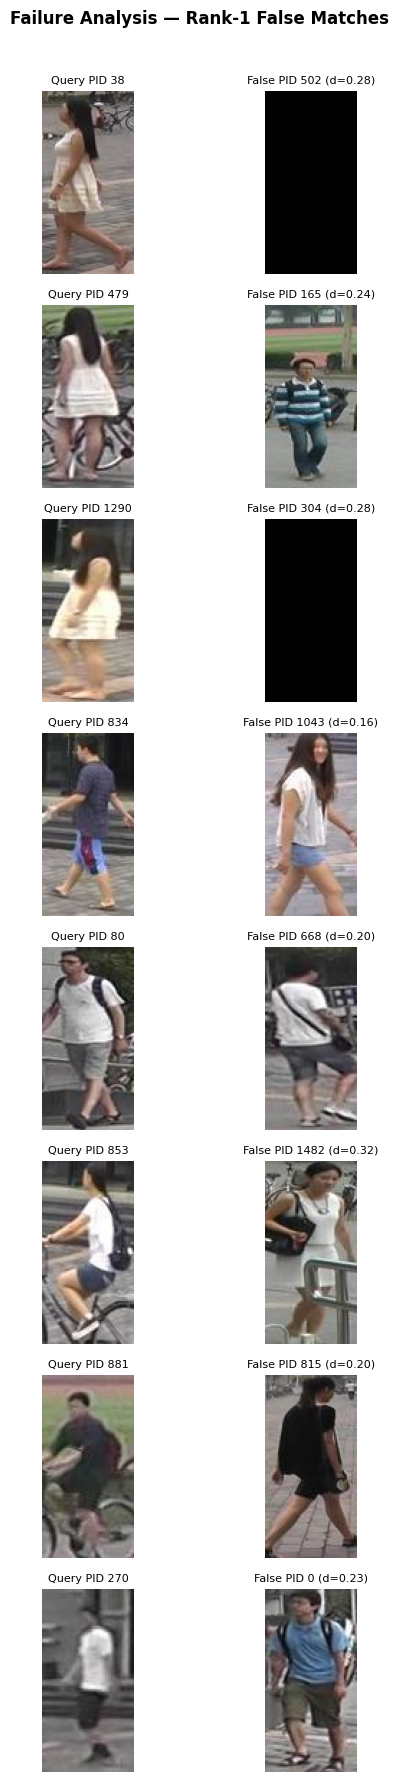

Failure analysis plot saved to /content/outputs/failure_analysis.png ✅


In [ ]:
# CELL 16 | Failure Analysis — Hard Negatives & False Positives (Fixed Bounds)
import numpy as np, cv2, matplotlib.pyplot as plt, glob
from pathlib import Path

ROOT       = Path("/content")
DATA_DIR   = ROOT / "data"
MARKET_DIR = DATA_DIR / "market1501" / "Market-1501-v15.09.15"
OUT        = ROOT / "outputs"

dist_mat = np.load(OUT / "dist_mat.npy")
q_pids   = np.load(OUT / "q_pids.npy")
g_pids   = np.load(OUT / "g_pids.npy")
q_camids = np.load(OUT / "q_camids.npy")
g_camids = np.load(OUT / "g_camids.npy")

# Find query and gallery files safely
query_files   = sorted([Path(f) for f in glob.glob(str(ROOT) + "/**/query/*.jpg", recursive=True)
                        if not Path(f).name.startswith(("-1", "0000"))])
gallery_files = sorted([Path(f) for f in glob.glob(str(ROOT) + "/**/bounding_box_test/*.jpg", recursive=True)
                        if not Path(f).name.startswith(("-1", "0000"))])

THUMB_W, THUMB_H = 64, 128

def read_thumb(file_path):
    if file_path is None or not Path(file_path).exists():
        return np.zeros((THUMB_H, THUMB_W, 3), dtype=np.uint8)
    img = cv2.imread(str(file_path))
    if img is None:
        return np.zeros((THUMB_H, THUMB_W, 3), dtype=np.uint8)
    return cv2.resize(img, (THUMB_W, THUMB_H))

# Identify Rank-1 failures (cross-camera protocol)
failures = []
for qi in range(min(len(query_files), dist_mat.shape[0])):
    order = np.argsort(dist_mat[qi])
    gp    = g_pids[order]
    gc    = g_camids[order]

    # Exclude same camera same identity (junk)
    keep  = ~((gp == q_pids[qi]) & (gc == q_camids[qi]))
    order_clean = order[keep]
    gp_clean    = gp[keep]

    if len(gp_clean) > 0 and gp_clean[0] != q_pids[qi]:
        failures.append({
            "q_idx" : qi,
            "g_idx" : order_clean[0],
            "dist"  : dist_mat[qi][order_clean[0]],
        })

print(f"Rank-1 failures : {len(failures)} / {dist_mat.shape[0]} ({len(failures)/dist_mat.shape[0]*100:.1f}%)")
print(f"Rank-1 accuracy : {100 - (len(failures)/dist_mat.shape[0]*100):.1f}%")

# Plot top failure cases safely
N_SHOW = min(8, len(failures))
if N_SHOW > 0:
    fig, axes = plt.subplots(N_SHOW, 2, figsize=(6, N_SHOW * 2.2))
    if N_SHOW == 1:
        axes = np.array([axes])

    for i, fail in enumerate(failures[:N_SHOW]):
        q_fp = query_files[fail["q_idx"]] if fail["q_idx"] < len(query_files) else None
        g_fp = gallery_files[fail["g_idx"]] if fail["g_idx"] < len(gallery_files) else None

        q_img = read_thumb(q_fp)
        g_img = read_thumb(g_fp)

        q_rgb = cv2.cvtColor(q_img, cv2.COLOR_BGR2RGB)
        g_rgb = cv2.cvtColor(g_img, cv2.COLOR_BGR2RGB)

        axes[i, 0].imshow(q_rgb)
        axes[i, 0].set_title(f"Query PID {q_pids[fail['q_idx']]}", fontsize=8)
        axes[i, 1].imshow(g_rgb)
        axes[i, 1].set_title(f"False PID {g_pids[fail['g_idx']]} (d={fail['dist']:.2f})", fontsize=8)

        for ax in axes[i]:
            ax.axis("off")

    plt.suptitle("Failure Analysis — Rank-1 False Matches", fontweight="bold", y=1.01)
    plt.tight_layout()
    plt.savefig(str(OUT / "failure_analysis.png"), dpi=120, bbox_inches="tight")
    plt.show()
    print(f"Failure analysis plot saved to {OUT / 'failure_analysis.png'} ✅")